
# 03 — Context-conditional allocation

The contribution that is most identifiably new, and it follows from one property of
the data that nobody had looked at: **the context flags act on the variance of demand,
not its level** (notebook 00).

A marginally calibrated allocator therefore hits its target *on average* while
systematically under-provisioning when the network is under stress — the failures
cluster exactly where they hurt most. The claim tested here:

> Marginal conformal calibration misses its nominal rate inside the elevated-risk
> context group; locally adaptive and Mondrian calibration close that gap at
> near-identical capacity cost.

This is falsifiable, and it is reported in both directions: it **holds on GP** and is
**correctly null on Robi**, which has no flag with elevated variance.

In [1]:
# --- Bootstrap: works locally, on Colab and on Kaggle ----------------------
# RUN THIS CELL FIRST, and re-run it after any kernel restart. Every later cell
# depends on it. If it fails, the next cell fails with "No module named bwalloc",
# which looks like a different problem but is not.
#
# On a hosted runtime it clones the repo (or pulls, on a re-run) and installs the
# package into the session, so `import bwalloc` keeps working even from a cell you
# run on its own after restarting. The repository is public; no token is needed.
import os, subprocess, sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
REPO = "https://github.com/sad-code-at/bwalloc.git"

def _find_root(start: Path):
    node = start
    while not (node / "src" / "bwalloc").exists() and node != node.parent:
        node = node.parent
    return node if (node / "src" / "bwalloc").exists() else None

ROOT = _find_root(Path.cwd())

if ROOT is None:
    # A repo uploaded as a Kaggle Dataset mounts read-only here; prefer it if present.
    for candidate in Path("/kaggle/input").glob("*/src/bwalloc"):
        ROOT = candidate.parent.parent
        break

if ROOT is None:
    on_kaggle = Path("/kaggle/working").exists()
    target = Path("/kaggle/working/bwalloc") if on_kaggle else Path("/content/bwalloc")
    if _find_root(target) is None:
        if os.system("git clone -q " + REPO + " " + str(target)) != 0 or _find_root(target) is None:
            raise RuntimeError(
                "Clone failed. On Kaggle, switch Internet ON in the right sidebar "
                "(Settings > Internet), then re-run this cell. See docs/KAGGLE.md."
            )
        print("cloned", REPO)
    else:
        os.system("git -C " + str(target) + " pull -q --ff-only")
        print("pulled latest into", target)
    os.chdir(target)
    ROOT = target
    # Install into the session so `import bwalloc` survives a kernel restart and
    # does not depend on this cell having set sys.path. --no-deps deliberately:
    # Kaggle and Colab curate their own numpy/pandas and we must not disturb them.
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".", "--no-deps"],
                   cwd=str(ROOT), capture_output=True)

sys.path.insert(0, str(ROOT / "src"))

try:
    import xgboost  # noqa: F401
except ImportError:
    !pip install -q xgboost

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import bwalloc as bw
from bwalloc.plots import use_paper_style

bw.set_seed()
use_paper_style()
pd.set_option("display.width", 200)
RESULTS = ROOT / "experiments" / "results"
# Scratch output for the exploratory notebooks. Only 07_paper_figures writes into
# paper/figures -- otherwise running notebook 00 or 05 silently overwrites a figure
# the paper cites, which is exactly the kind of drift this project exists to remove.
FIGURES = ROOT / "notebooks" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
_data = sorted((ROOT / "data").glob("*.csv"))
_res = sorted(RESULTS.glob("*.csv"))
print("bwalloc", bw.__version__, "at", ROOT)
print(f"  data/    {len(_data)} csv  ({', '.join(f.name for f in _data) or 'MISSING'})")
print(f"  results/ {len(_res)} csv")
if not _data:
    raise RuntimeError(
        "The trace CSVs are missing, so nothing will run. Re-run this cell to "
        "re-clone, or check that the repository was fetched completely."
    )

bwalloc 0.1.0 at D:\L4-T-1\EEE 402\project\bwalloc
  data/    2 csv  (gp_dhaka.csv, robi_dhaka3.csv)
  results/ 46 csv


In [2]:

from bwalloc.context import assign_binary_groups, flag_report, group_sizes
from bwalloc.data import load, sampling_profile
from bwalloc.features import FeatureConfig, build_features
from bwalloc.models import xgboost_point
from bwalloc.pipeline import coverage_table, run_allocation_backtest
from bwalloc.splits import rolling_origin

OPERATOR = "gp"
df = load(OPERATOR)
profile = sampling_profile(df)

# Which flags mark elevated *uncertainty*? Levene's test on detrended residuals.
report = flag_report(df, OPERATOR)
report[["flag", "n_on", "delta_mean", "p_level", "resid_sd_on",
        "resid_sd_off", "variance_ratio", "p_variance"]]

,flag,n_on,delta_mean,p_level,resid_sd_on,resid_sd_off,variance_ratio,p_variance
0,is_rain,131,4.499729,0.026156,21.798582,16.384587,1.330432,4.693899e-07
1,is_political_gathering,101,2.687343,0.166435,18.360115,17.188199,1.068181,2.597358e-01
2,is_powercut,118,-2.632671,0.130430,17.669598,17.265364,1.023413,8.322132e-01
3,is_event,275,-0.230929,0.855561,17.544381,17.251475,1.016979,5.709269e-01
4,is_drama,147,-1.522800,0.336682,17.363643,17.326340,1.002153,7.697360e-01
5,is_weekend,261,0.367821,0.769860,16.861666,17.530459,0.961850,9.399420e-01
6,is_holiday,49,-3.985884,0.110991,16.361893,17.369551,0.941987,3.860969e-01
7,is_offer,235,-5.730823,0.000005,15.857720,17.589059,0.901567,1.330046e-02
8,event,13,9.357609,0.026972,13.421753,17.352197,0.773490,9.424338e-02



### Group construction, and why it is a two-group split

The raw flags overlap (`rain ∩ gathering` = 33 rows), and Mondrian calibration needs
*disjoint* groups. A four-group split leaves the gathering group with ~20 calibration
residuals, and a group of *m* residuals cannot express a level finer than `1/(m+1)` —
τ = 0.99 needs 99. So the split is two groups: `elevated_risk = rain ∪ gathering`
against `baseline`. Both merged groups are the elevated-variance ones, so the merge is
principled rather than convenient.

`conformal.min_calibration_size` enforces this and **raises rather than clipping**.
Silently returning the largest residual would report a guarantee the data cannot
support — a subtler version of the error this project exists to correct.

In [3]:

from bwalloc.conformal import min_calibration_size

groups = assign_binary_groups(df).reindex(build_features(df, profile, FeatureConfig())[0].index)
print(group_sizes(groups).to_string(index=False), "\n")
for tau in (0.80, 0.90, 0.95, 0.99):
    print(f"tau={tau:.2f} needs at least {min_calibration_size(tau):3d} calibration residuals")

        group  n_rows  approx_calib  max_supported_tau
     baseline     689           172               0.99
elevated_risk     199            50               0.98 

tau=0.80 needs at least   4 calibration residuals
tau=0.90 needs at least   9 calibration residuals
tau=0.95 needs at least  19 calibration residuals
tau=0.99 needs at least  99 calibration residuals


## The result

Coverage by context group, pooled across folds, weighted by test-block size.

In [4]:

X, y = build_features(df, profile, FeatureConfig())
folds = rolling_origin(len(y), n_folds=8, calib_frac=0.30)
per_fold, allocations = run_allocation_backtest(
    X, y, folds, groups, model_factory=xgboost_point, taus=(0.80, 0.90, 0.95),
)
coverage_table(per_fold, "coverage")

method,tau,group,aci,adaptive,marginal,mondrian
0,0.80,ALL,0.804878,0.801126,0.786116,0.780488
1,0.80,baseline,0.830508,0.836158,0.830508,0.807910
2,0.80,elevated_risk,0.754190,0.731844,0.698324,0.726257
3,0.90,ALL,0.902439,0.874296,0.866792,0.870544
4,0.90,baseline,0.903955,0.903955,0.915254,0.898305
5,0.90,elevated_risk,0.899441,0.815642,0.770950,0.815642
6,0.95,ALL,0.953096,0.930582,0.930582,0.939962
7,0.95,baseline,0.954802,0.940678,0.963277,0.949153
8,0.95,elevated_risk,0.949721,0.910615,0.865922,0.921788


In [5]:

# The capacity cost of closing the gap.
coverage_table(per_fold, "mean_allocation_ratio")

method,tau,group,aci,adaptive,marginal,mondrian
0,0.80,ALL,1.091202,1.093990,1.080989,1.082060
1,0.80,baseline,1.090748,1.101793,1.091563,1.079462
2,0.80,elevated_risk,1.092529,1.079999,1.061743,1.088622
3,0.90,ALL,1.141908,1.136202,1.135683,1.135352
4,0.90,baseline,1.136576,1.144760,1.146468,1.128868
5,0.90,elevated_risk,1.153163,1.120659,1.116148,1.149732
6,0.95,ALL,1.198864,1.175332,1.184019,1.182725
7,0.95,baseline,1.199814,1.181775,1.195066,1.182155
8,0.95,elevated_risk,1.197843,1.163820,1.164030,1.185784


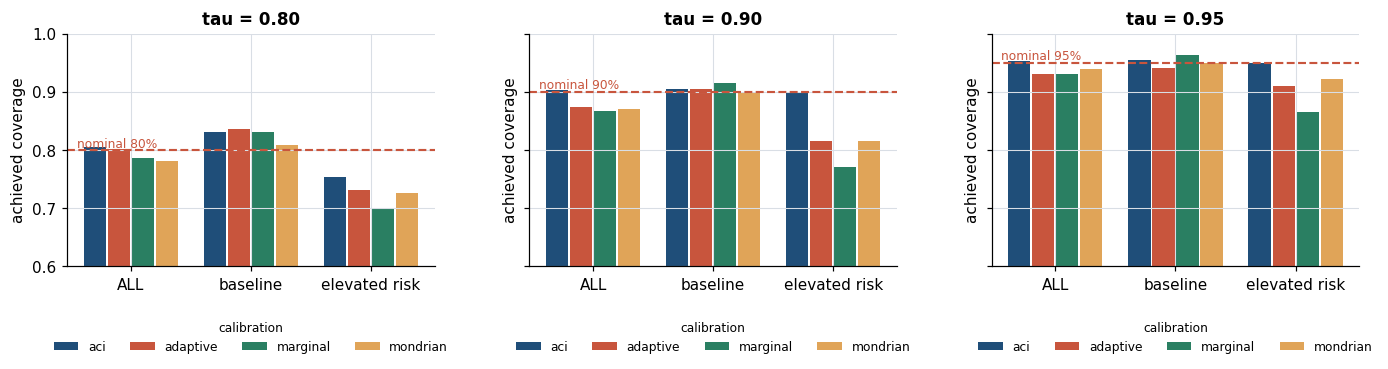

In [6]:

from bwalloc.plots import plot_coverage_by_group

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, tau in zip(axes, (0.80, 0.90, 0.95)):
    plot_coverage_by_group(per_fold, tau=tau, ax=ax)
    ax.set_title(f"tau = {tau:.2f}")
fig.tight_layout()
fig.savefig(FIGURES / f"fig4_coverage_by_group_{OPERATOR}.png", dpi=200, bbox_inches="tight")


## Reading the result, and the null on Robi

On GP the gap is large and consistent: at τ = 0.95, marginal calibration delivers
0.963 on the baseline group but **0.866** inside the elevated-risk group. Locally
adaptive calibration lifts that to 0.911 and Mondrian to 0.922.

Now switch `OPERATOR` to `"robi"` and re-run. On Robi **no flag has elevated
variance** — `is_powercut` and `is_event` actually mark *calmer* periods — and the
method correspondingly does nothing (τ = 0.95 elevated: marginal 0.889, adaptive
0.875, Mondrian 0.903).

That is the right outcome to report. The claim is not "context-conditional
calibration always helps"; it is "context-conditional calibration helps exactly when
context carries variance signal, and can be tested for in advance". The null on Robi
is what makes it a prediction rather than a story.

**Caveat to keep in the paper.** The elevated-risk group carries ~40 calibration
residuals, so per-group coverage estimates are reported with Clopper–Pearson
intervals and those intervals are wide. Robi carries five of the nine flags and no
rain annotation at all, and its group is 89 rows — directional only.